# 1. **(imports + setup)** 

In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

plt.style.use("ggplot")
sns.set_palette("deep")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# 2. knowing the real path

In [5]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    for file in filenames[:5]:
        print("   ", file)
    print("-"*60)

/kaggle/input
------------------------------------------------------------
/kaggle/input/datasets
------------------------------------------------------------
/kaggle/input/datasets/crawford
------------------------------------------------------------
/kaggle/input/datasets/crawford/emnist
    emnist-letters-mapping.txt
    emnist-letters-test.csv
    emnist-mnist-mapping.txt
    emnist-digits-train.csv
    emnist-bymerge-mapping.txt
------------------------------------------------------------
/kaggle/input/datasets/crawford/emnist/emnist_source_files
    emnist-digits-test-labels-idx1-ubyte
    emnist-bymerge-train-labels-idx1-ubyte
    emnist-letters-test-labels-idx1-ubyte
    emnist-byclass-train-images-idx3-ubyte
    emnist-byclass-test-images-idx3-ubyte
------------------------------------------------------------


# 3. **Load dataset**

In [6]:
DATA_DIR = "/kaggle/input/datasets/crawford/emnist"

TRAIN_PATH = f"{DATA_DIR}/emnist-balanced-train.csv"
TEST_PATH  = f"{DATA_DIR}/emnist-balanced-test.csv"
MAP_PATH   = f"{DATA_DIR}/emnist-balanced-mapping.txt"

train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (112800, 785)
Test shape : (18800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,45,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 4. Mapping file

In [8]:
mapping = pd.read_csv(MAP_PATH, sep=" ", header=None)
mapping.columns = ["label", "ascii"]
mapping["char"] = mapping["ascii"].apply(chr)

print("Classes:", len(mapping))
display(mapping.head(15))

Classes: 47


,label,ascii,char
0,0,48,0
1,1,49,1
2,2,50,2
3,3,51,3
4,4,52,4
5,5,53,5
6,6,54,6
7,7,55,7
8,8,56,8
9,9,57,9


# 5. Visualize raw data

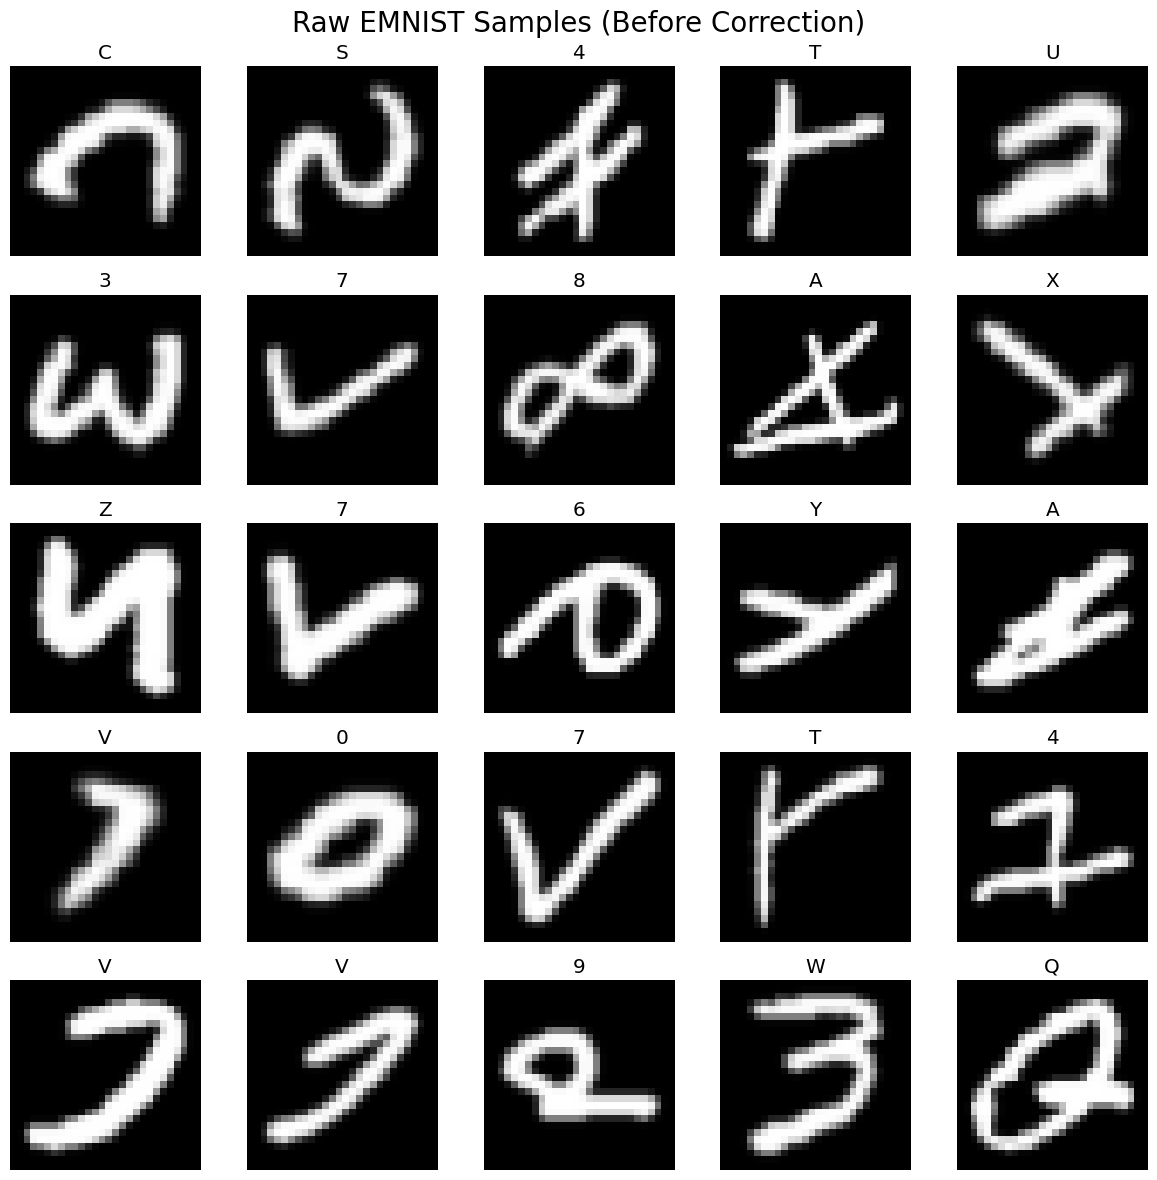

In [9]:
label_to_char = dict(zip(mapping.label, mapping.char))

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

samples = train_df.sample(25, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    label = row.iloc[0]
    image = row.iloc[1:].values.reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"{label_to_char[label]}")
    ax.axis("off")

plt.suptitle("Raw EMNIST Samples (Before Correction)", fontsize=20)
plt.tight_layout()
plt.show()

# 6. Separate features and labels

In [10]:
# ============================================================
# STEP 3.1 — Separate labels (y) and pixel values (X)
# ============================================================

# First column contains class labels
y_train = train_df.iloc[:, 0].values
y_test = test_df.iloc[:, 0].values

# Remaining 784 columns are image pixels
X_train = train_df.iloc[:, 1:].values
X_test = test_df.iloc[:, 1:].values

# Print shapes for validation
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

# Display unique labels count
print("\nNumber of unique classes:", len(np.unique(y_train)))
print("Classes:", sorted(np.unique(y_train))[:10], "...")

X_train shape: (112800, 784)
y_train shape: (112800,)
X_test shape : (18800, 784)
y_test shape : (18800,)

Number of unique classes: 47
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] ...


# 7. Reshape into images

X_train: (112800, 28, 28)
X_test : (18800, 28, 28)


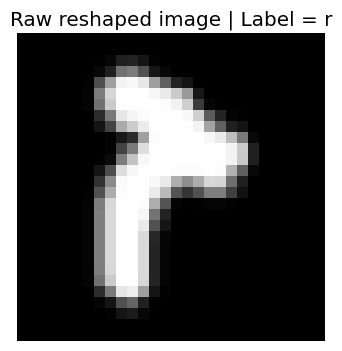

In [11]:
# ============================================================
# STEP 3.2 — Reshape flattened pixels into 28x28 images
# ============================================================

# Convert 784 vector -> 28x28 image
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# Validate new shape
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Visualize one raw sample
sample_idx = 0

plt.figure(figsize=(4, 4))
plt.imshow(X_train[sample_idx], cmap="gray")
plt.title(f"Raw reshaped image | Label = {label_to_char[y_train[sample_idx]]}")
plt.axis("off")
plt.show()

# 8. Preproccessing Fix EMNIST orientation

In [12]:
# ============================================================
# STEP 3.3 — Correct EMNIST orientation
# Rotate + flip images to normal readable direction
# ============================================================

def fix_emnist_orientation(images):
    """
    Fix EMNIST rotated / mirrored images.

    Process:
    1) transpose image
    2) horizontal flip

    Parameters:
        images: numpy array of shape (N, 28, 28)

    Returns:
        corrected images
    """
    
    corrected = np.array([
        np.fliplr(img.T) for img in images
    ])
    
    return corrected


# Apply correction
X_train = fix_emnist_orientation(X_train)
X_test = fix_emnist_orientation(X_test)

print("Orientation correction applied.")

Orientation correction applied.


# 9. Before / After visualization

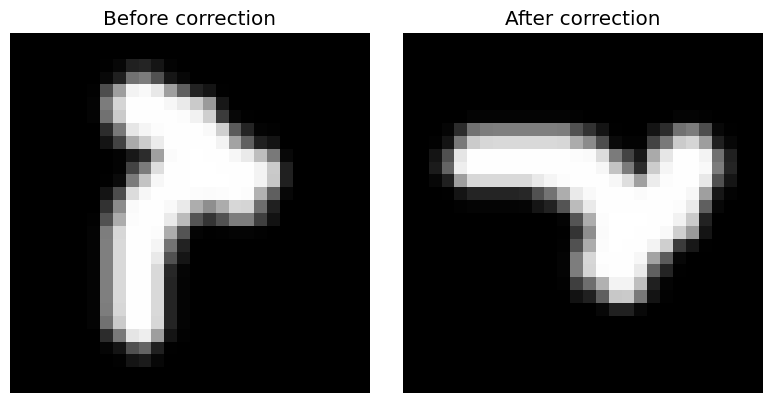

In [13]:
# ============================================================
# STEP 3.4 — Visual validation
# Compare raw image vs corrected image
# ============================================================

# Get one sample from original dataframe
sample_row = train_df.iloc[0, 1:].values.reshape(28, 28)

# Correct it manually for comparison
fixed_sample = np.fliplr(sample_row.T)

# Create side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Before
ax[0].imshow(sample_row, cmap="gray")
ax[0].set_title("Before correction")
ax[0].axis("off")

# After
ax[1].imshow(fixed_sample, cmap="gray")
ax[1].set_title("After correction")
ax[1].axis("off")

plt.tight_layout()
plt.show()

# 10. Normalize pixel values

In [14]:
# ============================================================
# STEP 3.5 — Normalize images
# Convert pixel range from [0, 255] → [0, 1]
# ============================================================

X_train = X_train.astype("float32") / 255.0  # normalize training images
X_test = X_test.astype("float32") / 255.0    # normalize test images

# Check value range after normalization
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


# 11. Verify labels

In [15]:
# ============================================================
# STEP 3.6 — Verify labels (no encoding needed)
# ============================================================

# EMNIST Balanced already uses integer labels (0–46)
print("Sample labels:", y_train[:10])

# Number of classes
num_classes = len(np.unique(y_train))
print("Total classes:", num_classes)

Sample labels: [45 36 43 15  4 42 26 32 20  1]
Total classes: 47


# 12. One-hot encoding

In [22]:
# ============================================================
# STEP 3.7 — One-hot encode labels for CNN training
# ============================================================

from tensorflow.keras.utils import to_categorical

# Convert labels into one-hot format
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Check shape after encoding
print("y_train_cat shape:", y_train_cat.shape)

# Example conversion:
# label 5 → [0,0,0,0,0,1,0,...]

y_train_cat shape: (112800, 47)


# 13. Improve image clarity (thresholding)

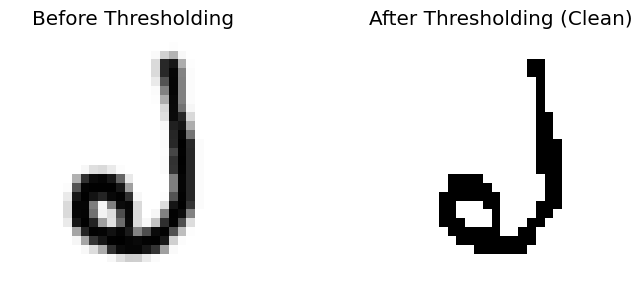

In [41]:
# ============================================================
# STEP — Improve image clarity using thresholding
# Goal: remove noise and enhance character visibility
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Use inverted images as base (better contrast for handwriting)
X_train_base = X_train_inv.copy()
X_test_base = X_test_inv.copy()

# Threshold value (tunable parameter)
threshold = 0.3  # lower = more detail, higher = cleaner image

# Apply binary thresholding
X_train_thresh = (X_train_base > threshold).astype("float32")
X_test_thresh = (X_test_base > threshold).astype("float32")

# ============================================================
# Visualization to compare before and after
# ============================================================

idx = np.random.randint(len(X_train_base))

plt.figure(figsize=(8, 3))

# Before thresholding
plt.subplot(1, 2, 1)
plt.imshow(X_train_base[idx], cmap="gray")
plt.title("Before Thresholding")
plt.axis("off")

# After thresholding
plt.subplot(1, 2, 2)
plt.imshow(X_train_thresh[idx], cmap="gray")
plt.title("After Thresholding (Clean)")
plt.axis("off")

plt.tight_layout()
plt.show()

# 14. Class distribution

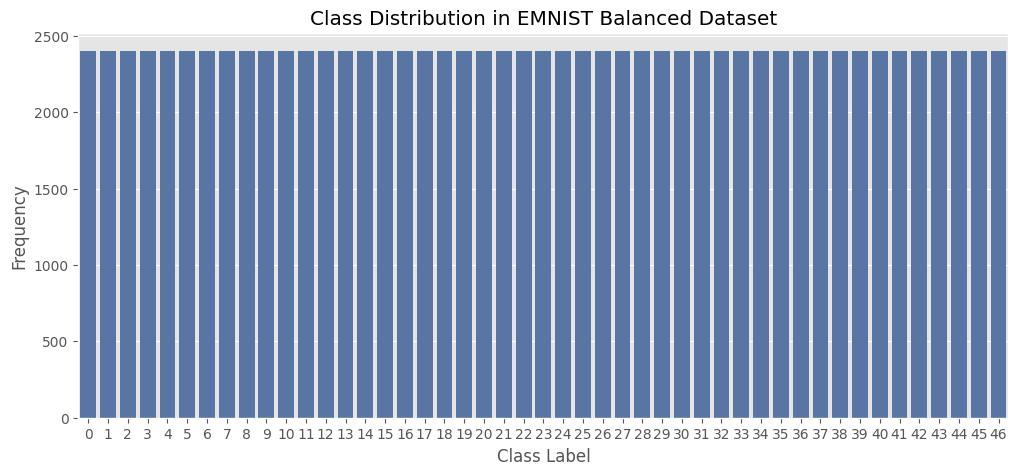

In [42]:
# ============================================================
# STEP 4.1 — Class distribution analysis
# ============================================================

import seaborn as sns
import pandas as pd

# Convert labels to DataFrame for plotting
df_labels = pd.DataFrame(y_train, columns=["label"])

plt.figure(figsize=(12,5))

# Count each class frequency
sns.countplot(x="label", data=df_labels)

plt.title("Class Distribution in EMNIST Balanced Dataset")
plt.xlabel("Class Label")
plt.ylabel("Frequency")

plt.show()

# 15. Map labels to characters

In [43]:
# ============================================================
# STEP 4.2 — Create label-to-character mapping
# ============================================================

label_to_char = dict(zip(mapping.label, mapping.char))

print("Example mapping:")
for i in list(label_to_char.keys())[:10]:
    print(i, "->", label_to_char[i])

Example mapping:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
8 -> 8
9 -> 9


# 16. Visualize samples per class

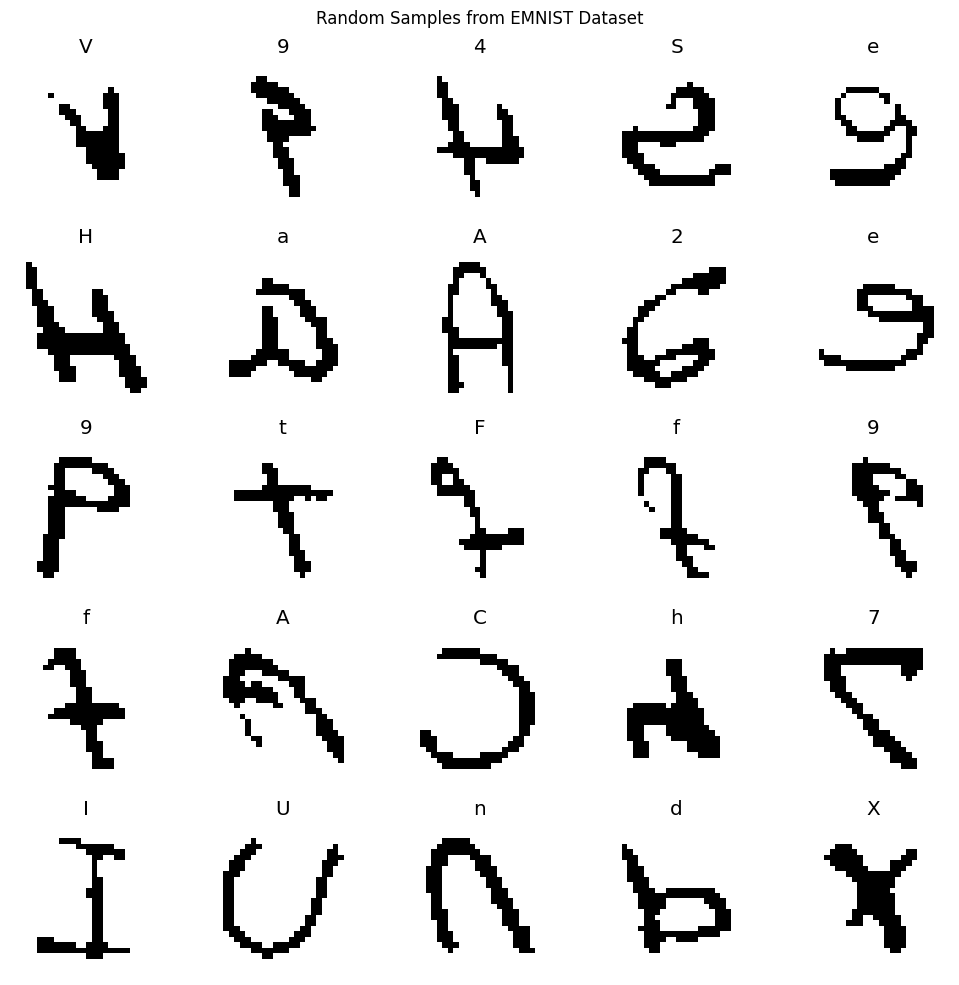

In [44]:
# ============================================================
# STEP 4.3 — Visualize random samples from dataset
# ============================================================

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for i in range(25):
    idx = np.random.randint(len(X_train_thresh))
    
    img = X_train_thresh[idx]
    label = y_train[idx]

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"{label_to_char[label]}")
    axes[i].axis("off")

plt.suptitle("Random Samples from EMNIST Dataset")
plt.tight_layout()
plt.show()

# 17. Mean image per class

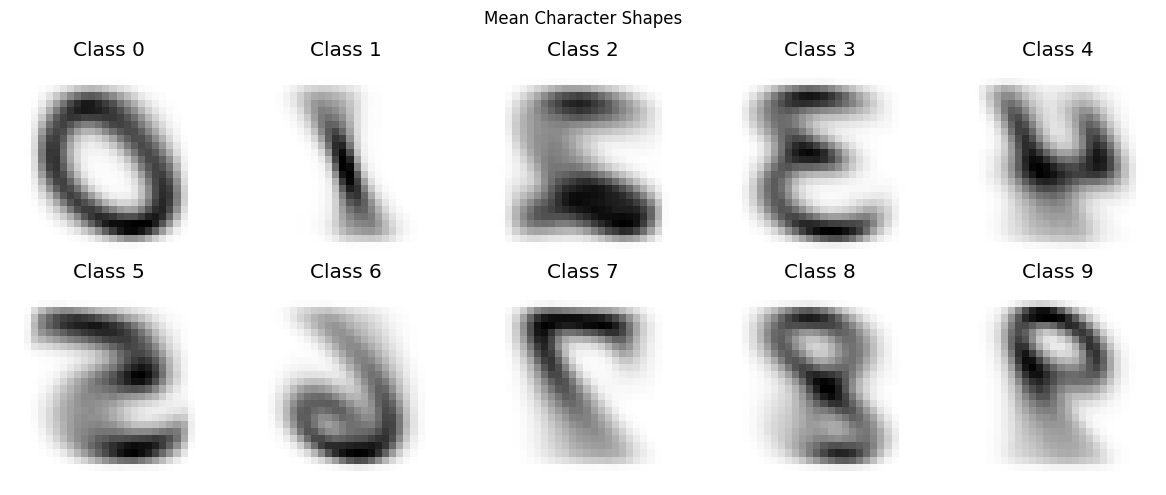

In [45]:
# ============================================================
# STEP 4.4 — Mean image per class
# ============================================================

classes = np.unique(y_train)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, cls in enumerate(classes[:10]):
    # Get all images of this class
    class_images = X_train_thresh[y_train == cls]
    
    # Compute mean image
    mean_img = np.mean(class_images, axis=0)
    
    axes[i].imshow(mean_img, cmap="gray")
    axes[i].set_title(f"Class {label_to_char[cls]}")
    axes[i].axis("off")

plt.suptitle("Mean Character Shapes")
plt.tight_layout()
plt.show()

# 18. Pixel intensity distribution

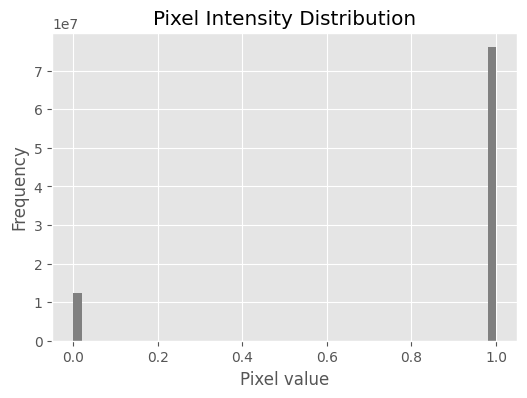

In [46]:
# ============================================================
# STEP 4.5 — Pixel intensity distribution
# ============================================================

plt.figure(figsize=(6,4))

plt.hist(X_train_thresh.ravel(), bins=50, color="gray")
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")

plt.show()

## 19. prepare and build CNN model

Train shape: (112800, 28, 28, 1)
Test shape : (18800, 28, 28, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,757,711 (6.71 MB)

 Trainable params: 1,757,263 (6.70 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
882/882 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.4129 - loss: 2.1674 - val_accuracy: 0.8143 - val_loss: 0.5272 - learning_rate: 0.0010
Epoch 2/25
882/882 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.7666 - loss: 0.7152 - val_accuracy: 0.8501 - val_loss: 0.4448 - learning_rate: 0.0010
Epoch 3/25
882/882 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8030 - loss: 0.5917 - val_accuracy: 0.8618 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 4/25
882/882 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8187 - loss: 0.5367 - val_accuracy: 0.8702 - val_loss: 0.3725 - learning_rate: 0.0010
Epoch 5/25
882/882 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8289 - loss: 0.4986 - val_accuracy: 0.8656 - val_loss: 0.3809 - learning_rate: 0.0010
Epoch 6/25
881/882 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8360 - loss: 0.4808
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
882/882 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.8360 - los

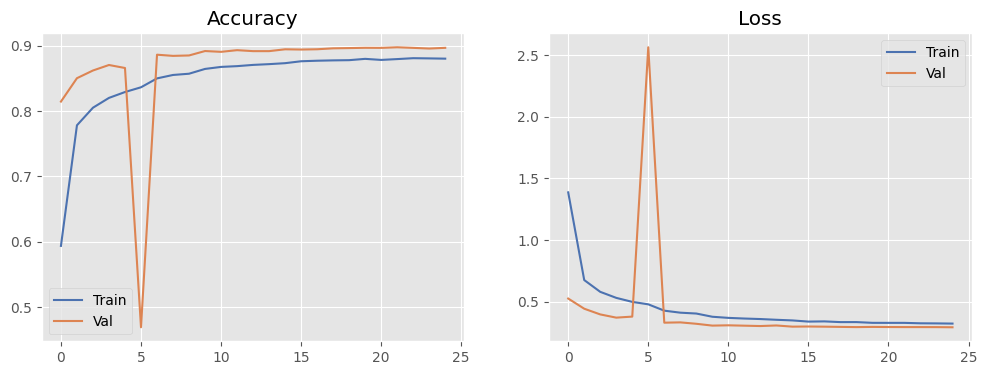

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


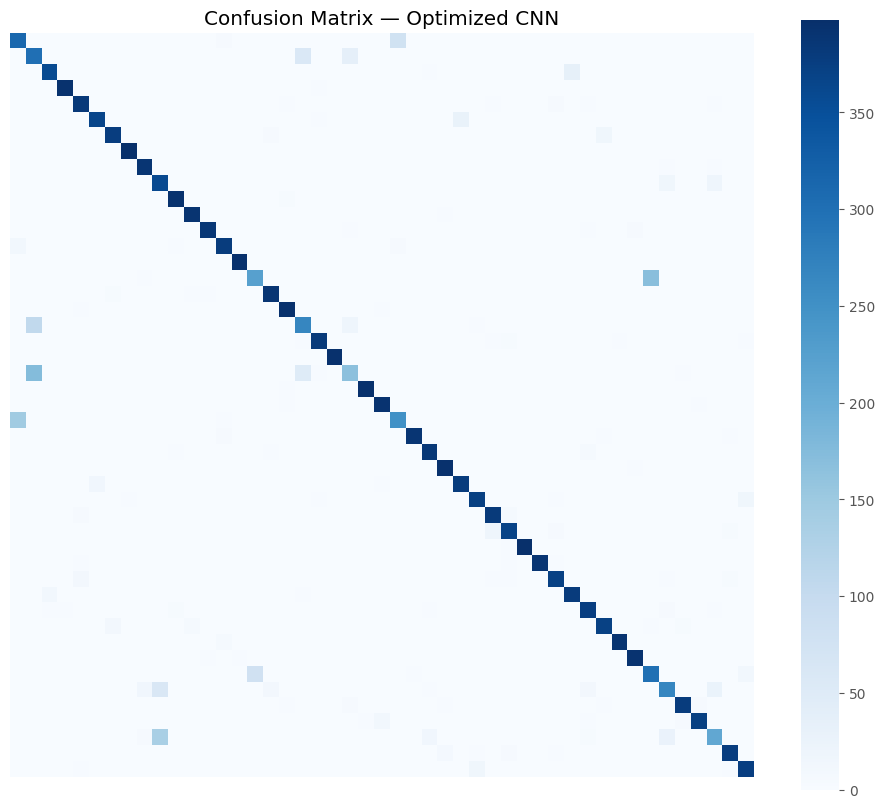

In [52]:
# ============================================================
# FULL CNN — EMNIST CHARACTER RECOGNITION
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 1 — Prepare input for CNN
# ============================================================

X_train_cnn = X_train_thresh.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_thresh.reshape(-1, 28, 28, 1)

print("Train shape:", X_train_cnn.shape)
print("Test shape :", X_test_cnn.shape)

# ============================================================
# STEP 2 — Data Augmentation
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train_cnn)

# ============================================================
# STEP 3 — Optimized CNN Architecture
# ============================================================

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())

# Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

# Output layer (47 classes)
model.add(layers.Dense(num_classes, activation='softmax'))

# ============================================================
# STEP 4 — Compile model
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# STEP 5 — Callbacks (Optimization)
# ============================================================

lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# ============================================================
# STEP 6 — Train model
# ============================================================

history = model.fit(
    datagen.flow(X_train_cnn, y_train_cat, batch_size=128),
    validation_data=(X_test_cnn, y_test_cat),
    epochs=25,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

# ============================================================
# STEP 7 — Evaluate model
# ============================================================

test_loss, test_acc = model.evaluate(X_test_cnn, y_test_cat, verbose=1)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# ============================================================
# STEP 8 — Training curves
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

# ============================================================
# STEP 9 — Confusion Matrix
# ============================================================

y_pred = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", square=True, cbar=True,
            xticklabels=False, yticklabels=False)

plt.title("Confusion Matrix — Optimized CNN")
plt.show()

# 20. Final STEP Which Build our CRNN

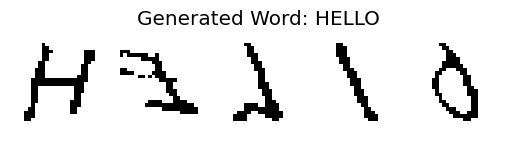

Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, None, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, None, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, None, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, None, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, None, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, None, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, None, 896)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 128)      │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, None, 48)       │         6,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,312,816 (5.01 MB)

 Trainable params: 1,312,816 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# ============================================================
# FULL CRNN OCR SYSTEM — IMAGE → WORD RECOGNITION
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import random

# ============================================================
# STEP 1 — Character mapping (EMNIST)
# ============================================================

label_to_char = dict(zip(mapping.label, mapping.char))
num_chars = len(label_to_char) + 1  # +1 for CTC blank token

# ============================================================
# STEP 2 — Synthetic word generator (from EMNIST letters)
# ============================================================

def get_random_char_image(char, X_data, y_data):
    """Return a random image of a given character"""
    label = [k for k, v in label_to_char.items() if v.upper() == char.upper()]
    if len(label) == 0:
        return None
    label = label[0]
    idx = np.random.choice(np.where(y_data == label)[0])
    return X_data[idx]

def create_word_image(word, X_data, y_data):
    """Create a word image by concatenating character images"""
    imgs = []
    
    for c in word:
        img = get_random_char_image(c, X_data, y_data)
        if img is not None:
            imgs.append(img)
    
    if len(imgs) == 0:
        return None
    
    return np.concatenate(imgs, axis=1)

# ============================================================
# STEP 3 — CRNN MODEL (CNN + BiLSTM)
# ============================================================

input_img = layers.Input(shape=(28, None, 1))

# CNN feature extractor
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(input_img)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)

# Convert CNN output to sequence
shape = tf.keras.backend.int_shape(x)
x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

# BiLSTM for sequence modeling
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

# Output layer (characters + blank for CTC)
output = layers.Dense(num_chars, activation='softmax')(x)

crnn_model = models.Model(inputs=input_img, outputs=output)

# ============================================================
# STEP 4 — CTC LOSS
# ============================================================

def ctc_loss(y_true, y_pred):
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred)

crnn_model.compile(optimizer='adam', loss=ctc_loss)

# ============================================================
# STEP 5 — Example word generation (demo)
# ============================================================

word = "HELLO"

sample_img = create_word_image(word, X_train_thresh, y_train)

if sample_img is not None:
    import matplotlib.pyplot as plt
    
    plt.imshow(sample_img, cmap='gray')
    plt.title(f"Generated Word: {word}")
    plt.axis('off')
    plt.show()

# ============================================================
# STEP 6 — Model summary
# ============================================================

crnn_model.summary()

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 35.8180 - val_loss: 18.3073
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 18.4346 - val_loss: 18.0725
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 18.2098 - val_loss: 17.9523
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 18.1289 - val_loss: 17.9383
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 18.1117 - val_loss: 17.9313
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 18.1019 - val_loss: 17.9272
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 18.0943 - val_loss: 17.9238
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 18.0878 - val_loss: 17.9207
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 18.0825 - val_loss: 17.9175
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 18.0763 - val_loss: 17.9141
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
Predicted: 


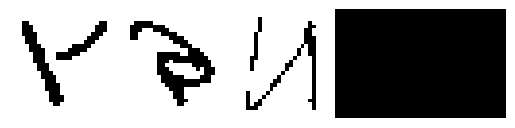

In [64]:
# ============================================================
# FULL CRNN OCR SYSTEM — FIXED (TRAIN + INFER + DECODE)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import random
import matplotlib.pyplot as plt

# ============================================================
# STEP 1 — CHARACTER MAPPING
# ============================================================

label_to_char = dict(zip(mapping.label, mapping.char))
char_to_label = {v: k for k, v in label_to_char.items()}

num_classes = len(label_to_char) + 1
blank_index = num_classes - 1

# ============================================================
# STEP 2 — WORD GENERATION
# ============================================================

def get_char_img(c, X, y):
    if c.upper() not in char_to_label:
        return None
    label = char_to_label[c.upper()]
    idx = np.random.choice(np.where(y == label)[0])
    return X[idx]

def make_word(word, X, y):
    imgs = []
    for c in word:
        img = get_char_img(c, X, y)
        if img is not None:
            imgs.append(img)
    if len(imgs) == 0:
        return None
    return np.concatenate(imgs, axis=1)

def generate_dataset(n, X, y):
    imgs, words = [], []
    vocab = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    
    for _ in range(n):
        w = "".join(random.choice(vocab) for _ in range(random.randint(3, 7)))
        img = make_word(w, X, y)
        if img is not None:
            words.append(w)
            imgs.append(img)
    
    return imgs, words

# ============================================================
# STEP 3 — FIX IMAGE WIDTH
# ============================================================

MAX_WIDTH = 128

def pad(img):
    out = np.zeros((28, MAX_WIDTH))
    w = min(img.shape[1], MAX_WIDTH)
    out[:, :w] = img[:, :w]
    return out

train_imgs, train_words = generate_dataset(2000, X_train_thresh, y_train)

X = np.array([pad(i) for i in train_imgs])
X = X.reshape(-1, 28, 128, 1)

# ============================================================
# STEP 4 — LABEL ENCODING
# ============================================================

max_len = 10

def encode(w):
    return [char_to_label[c] for c in w]

def pad_labels(labels):
    out = np.ones((len(labels), max_len)) * -1
    for i, l in enumerate(labels):
        out[i, :len(l)] = l
    return out

y = pad_labels([encode(w) for w in train_words])

# ============================================================
# STEP 5 — CTC LENGTHS
# ============================================================

input_length = np.ones((len(X), 1)) * (128 // 4)
label_length = np.array([[len(w)] for w in train_words])

dummy = np.zeros((len(X), 1))

# ============================================================
# STEP 6 — CRNN MODEL (FIXED INPUT NAMES)
# ============================================================

input_img = layers.Input(shape=(28, 128, 1), name="image")

x = layers.Conv2D(32, 3, padding="same", activation="relu")(input_img)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

shape = tf.keras.backend.int_shape(x)
x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

y_pred = layers.Dense(num_classes, activation="softmax")(x)

# ============================================================
# STEP 7 — CTC MODEL (FIXED INPUT NAMES)
# ============================================================

labels_in = layers.Input(shape=(None,), name="labels")
input_len_in = layers.Input(shape=(1,), name="input_length")
label_len_in = layers.Input(shape=(1,), name="label_length")

def ctc_loss(args):
    y_pred, labels, input_len, label_len = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_len, label_len)

loss_out = layers.Lambda(ctc_loss)(
    [y_pred, labels_in, input_len_in, label_len_in]
)

ctc_model = models.Model(
    inputs=[input_img, labels_in, input_len_in, label_len_in],
    outputs=loss_out
)

ctc_model.compile(optimizer="adam", loss=lambda y_true, y_pred: y_pred)

# ============================================================
# STEP 8 — TRAINING (FIXED KEYS)
# ============================================================

ctc_model.fit(
    x={
        "image": X,
        "labels": y,
        "input_length": input_length,
        "label_length": label_length
    },
    y=dummy,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

# ============================================================
# STEP 9 — INFERENCE MODEL
# ============================================================

base_model = tf.keras.Model(inputs=input_img, outputs=y_pred)

# ============================================================
# STEP 10 — DECODER
# ============================================================

char_list = [""] * num_classes
for k, v in label_to_char.items():
    char_list[k] = v

def decode(pred):
    pred = np.argmax(pred, axis=-1)[0]
    text = []
    prev = -1

    for p in pred:
        if p == blank_index:
            prev = p
            continue
        if p != prev:
            text.append(char_list[p])
        prev = p

    return "".join(text)

def predict(img):
    img = np.expand_dims(img, axis=0)
    pred = base_model.predict(img)
    return decode(pred)

# ============================================================
# STEP 11 — TEST
# ============================================================

i = np.random.randint(len(X))
img = X[i]

print("Predicted:", predict(img))

plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# 